In [2]:
from src.feature_builder import big_table
df = big_table()
df.head()

,Driver,TeamName,Year,EventName,IsSprint,RecentQForm,driver_points_last_3,team_points_last_3,WeekendRainFlag,AvgPreQualiTemp,...,SessionRank_SQ,SessionRank_SS,TheoreticalDelta_FP1,TheoreticalDelta_FP2,TheoreticalDelta_FP3,TheoreticalDelta_Q,TheoreticalDelta_SQ,TheoreticalDelta_SS,Q_Rank_LastYear,Q_Delta_LastYear
0,ALB,Williams,2022,Abu Dhabi Grand Prix,0,14.000000,0.0,0.0,0,43.975238,...,NaN,NaN,1.151,1.617,1.027,2.204,NaN,NaN,NaN,NaN
1,ALB,Williams,2022,Australian Grand Prix,0,15.000000,0.0,0.0,0,32.075949,...,NaN,NaN,3.002,2.746,1.752,2.003,NaN,NaN,NaN,NaN
2,ALB,Williams,2022,Austrian Grand Prix,1,15.000000,0.0,0.0,0,38.452475,...,18.0,NaN,1.190,1.262,NaN,1.359,1.915,NaN,NaN,NaN
3,ALB,Williams,2022,Azerbaijan Grand Prix,0,17.666667,2.0,2.0,0,45.661702,...,NaN,NaN,3.011,3.462,2.418,3.287,NaN,NaN,NaN,NaN
4,ALB,Williams,2022,Belgian Grand Prix,0,15.333333,0.0,0.0,0,20.267187,...,NaN,NaN,0.922,2.013,1.760,1.614,NaN,NaN,NaN,NaN


In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# 1. Kopiujemy dane z Feature Buildera
data = df.copy()

# 2. Usuwamy kolumny tekstowe lub zamieniamy je na liczby (Label Encoding)
le = LabelEncoder()
for col in ["Driver", "TeamName", "EventName"]:
    if col in data.columns:
        data[col] = le.fit_transform(data[col].astype(str))

# 3. Definiujemy cel: przewidujemy pozycję w kwalifikacjach
target_col = "SessionRank_Q"

# ANTI-LEAKAGE SHIELD: Szukamy wszystkich kolumn kwalifikacyjnych oprócz targetu
q_columns = [
    col for col in data.columns if col.endswith("_Q") and col != target_col
]

meta_columns = ["TeamSlug"]
columns_to_drop = q_columns + meta_columns + [target_col]

# Pozostawiamy do usunięcia tylko te, które faktycznie istnieją w tabeli
columns_to_drop = [c for c in columns_to_drop if c in data.columns]

X = data.drop(columns=columns_to_drop)
y = data[target_col]

# Usuwamy wiersze, w których target jest pusty
X = X[y.notna()]
y = y.dropna()

# 4. Chronologiczny podział danych (Szeregi czasowe)
train_mask = X["Year"] < 2025
test_mask = X["Year"] == 2025

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

# Usuwamy kolumnę 'Year' ze zbiorów cech
X_train = X_train.drop(columns=["Year"])
X_test = X_test.drop(columns=["Year"])

# 5. Inicjalizacja i pętla treningowa 5 modeli
print("=== TRENOWANIE MODELI ===")
models = {
    "Random Forest": RandomForestRegressor(n_estimators=150, max_depth=4, random_state=1, n_jobs=-1),
    "XGBoost": xgb.XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=4, random_state=67, n_jobs=-1),
    "LightGBM": lgb.LGBMRegressor(n_estimators=150, learning_rate=0.05, max_depth=4, random_state=1, n_jobs=-1, verbose=-1),
    "CatBoost": CatBoostRegressor(iterations=150, learning_rate=0.05, depth=4, random_state=1, verbose=0)
}

# Słownik przechowujący wyniki przewidywań każdego modelu
predictions_dict = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions_dict[name] = model.predict(X_test)
    print(f"[{name}] Zakończono trenowanie.")

print("Wszystkie modele gotowe do ewaluacji!")

=== TRENOWANIE MODELI ===
[Random Forest] Zakończono trenowanie.
[XGBoost] Zakończono trenowanie.
[LightGBM] Zakończono trenowanie.
[CatBoost] Zakończono trenowanie.
Wszystkie modele gotowe do ewaluacji!


=== 2. WAŻNOŚĆ CECH (Ujednolicony Benchmark: GAIN IMPORTANCE) ===

TOP 10 CECH – RANDOM FOREST (Gain/Gini):
               Cecha Ważność
         RecentQForm  0.5239
driver_points_last_3  0.1175
  team_points_last_3  0.1066
     SessionRank_FP3  0.0820
     SessionRank_FP2  0.0457
TheoreticalDelta_FP1  0.0228
   DeltaToLeader_FP3  0.0140
   DeltaToLeader_FP2  0.0108
    Q_Delta_LastYear  0.0108
   DeltaToLeader_FP1  0.0104
--------------------------------------------------
TOP 10 CECH – XGBOOST (Gain):
               Cecha Ważność
         RecentQForm  0.2451
driver_points_last_3  0.1341
  team_points_last_3  0.0972
     SessionRank_FP3  0.0552
     SessionRank_FP2  0.0517
      SessionRank_SQ  0.0314
TheoreticalDelta_FP1  0.0268
   DeltaToLeader_FP1  0.0261
   DeltaToLeader_FP2  0.0250
    Q_Delta_LastYear  0.0241
--------------------------------------------------
TOP 10 CECH – LIGHTGBM (Wymuszony Gain - Znormalizowany):
               Cecha Ważność
         RecentQForm  0.4127
  team

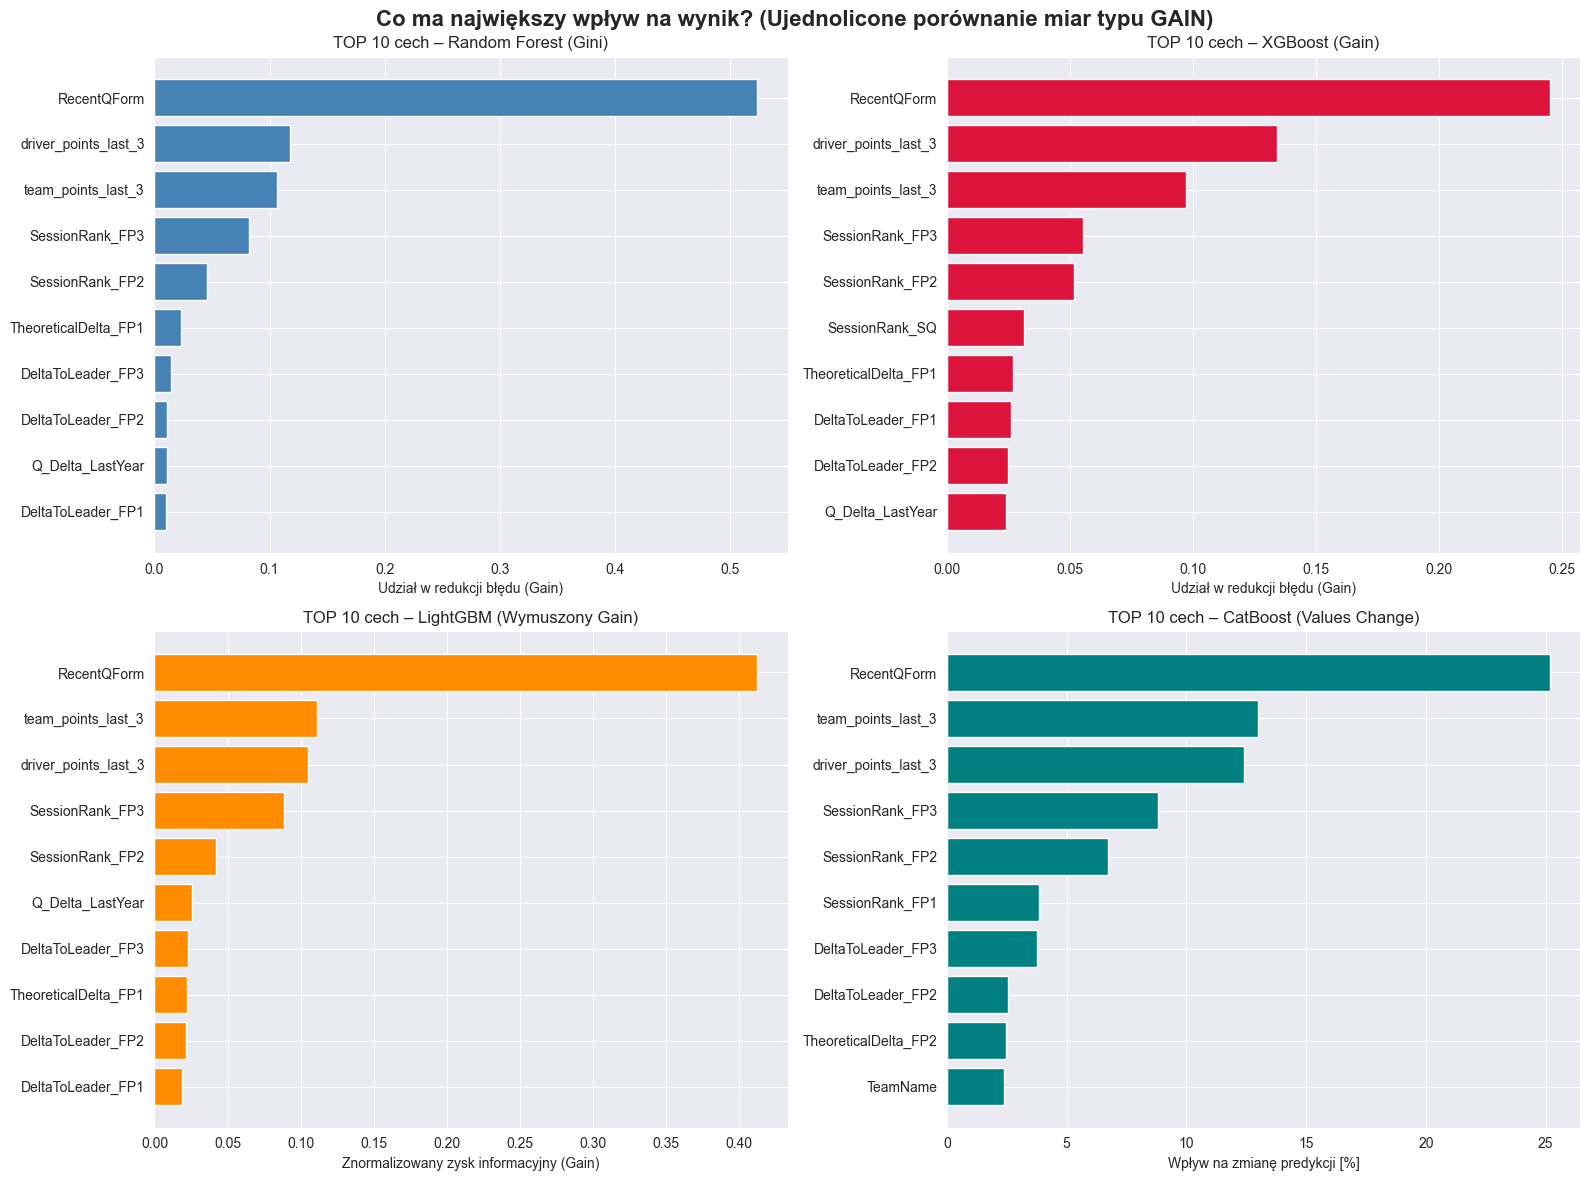

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

print("=== 2. WAŻNOŚĆ CECH (Ujednolicony Benchmark: GAIN IMPORTANCE) ===")

model_rf = models["Random Forest"]
model_xgb = models["XGBoost"]
model_lgb = models["LightGBM"]
model_cb = models["CatBoost"]

df_imp_rf = pd.DataFrame({"Cecha": X_train.columns, "Ważność": model_rf.feature_importances_}).sort_values(by="Ważność", ascending=False)
df_imp_xgb = pd.DataFrame({"Cecha": X_train.columns, "Ważność": model_xgb.feature_importances_}).sort_values(by="Ważność", ascending=False)

# Wyciągamy ważność po Gain
lgb_gain_importance = model_lgb.booster_.feature_importance(importance_type='gain')
# Normalizujemy do procentów/ułamka, żeby skala pasowała do reszty modeli
lgb_gain_normalized = lgb_gain_importance / lgb_gain_importance.sum()
df_imp_lgb = pd.DataFrame({"Cecha": X_train.columns, "Ważność": lgb_gain_normalized}).sort_values(by="Ważność", ascending=False)

df_imp_cb = pd.DataFrame({"Cecha": X_train.columns, "Ważność": model_cb.feature_importances_}).sort_values(by="Ważność", ascending=False)

print("\nTOP 10 CECH – RANDOM FOREST (Gain/Gini):")
print(df_imp_rf.head(10).to_string(index=False, formatters={"Ważność": "{:.4f}".format}))
print("-" * 50)
print("TOP 10 CECH – XGBOOST (Gain):")
print(df_imp_xgb.head(10).to_string(index=False, formatters={"Ważność": "{:.4f}".format}))
print("-" * 50)
print("TOP 10 CECH – LIGHTGBM (Wymuszony Gain - Znormalizowany):")
print(df_imp_lgb.head(10).to_string(index=False, formatters={"Ważność": "{:.4f}".format}))
print("-" * 50)
print("TOP 10 CECH – CATBOOST (PredictionValuesChange):")
print(df_imp_cb.head(10).to_string(index=False, formatters={"Ważność": "{:.4f}".format}))
print("\n" + "=" * 50 + "\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Górny lewy: Random Forest
top_10_rf = df_imp_rf.head(10)
axes[0, 0].barh(top_10_rf["Cecha"][::-1], top_10_rf["Ważność"][::-1], color="steelblue")
axes[0, 0].set_title("TOP 10 cech – Random Forest (Gini)")
axes[0, 0].set_xlabel("Udział w redukcji błędu (Gain)")

# Górny prawy: XGBoost
top_10_xgb = df_imp_xgb.head(10)
axes[0, 1].barh(top_10_xgb["Cecha"][::-1], top_10_xgb["Ważność"][::-1], color="crimson")
axes[0, 1].set_title("TOP 10 cech – XGBoost (Gain)")
axes[0, 1].set_xlabel("Udział w redukcji błędu (Gain)")

# Dolny lewy: LightGBM (Teraz też jako Gain!)
top_10_lgb = df_imp_lgb.head(10)
axes[1, 0].barh(top_10_lgb["Cecha"][::-1], top_10_lgb["Ważność"][::-1], color="darkorange")
axes[1, 0].set_title("TOP 10 cech – LightGBM (Wymuszony Gain)")
axes[1, 0].set_xlabel("Znormalizowany zysk informacyjny (Gain)")

# Dolny prawy: CatBoost
top_10_cb = df_imp_cb.head(10)
axes[1, 1].barh(top_10_cb["Cecha"][::-1], top_10_cb["Ważność"][::-1], color="teal")
axes[1, 1].set_title("TOP 10 cech – CatBoost (Values Change)")
axes[1, 1].set_xlabel("Wpływ na zmianę predykcji [%]")

plt.suptitle("Co ma największy wpływ na wynik? (Ujednolicone porównanie miar typu GAIN)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


🏆 GLOBALNE PODSUMOWANIE SKUTECZNOŚCI MODELI (SEZON 2025):
              Ogólne MAE MAE Typu P1 Trafione P1 Skuteczność P1 [%] Top 3 Accuracy [%]
XGBoost             2.92        1.58           7               29.2               70.8
LightGBM            2.88        1.50           6               25.0               79.2
CatBoost            2.88        1.79           5               20.8               75.0
Random Forest       3.01        1.96           3               12.5               75.0


🏁 RAPORT SZCZEGÓŁOWY PER GRAND PRIX (SEZON 2025):
-------------------------------------------------------------------------

🏎️  ABU DHABI GRAND PRIX
🥇 Prawdziwe Pole Position (Actual): VER
   ↳ Typowania modeli:
      ▪ Random Forest  : ❌ PUDŁO (Kierowca NOR zajął realnie P2)
      ▪ XGBoost        : ❌ PUDŁO (Kierowca NOR zajął realnie P2)
      ▪ LightGBM       : ❌ PUDŁO (Kierowca NOR zajął realnie P2)
      ▪ CatBoost       : ❌ PUDŁO (Kierowca NOR zajął realnie P2)

🏎️  AUSTRALIAN GRAND PRIX
🥇 Pra

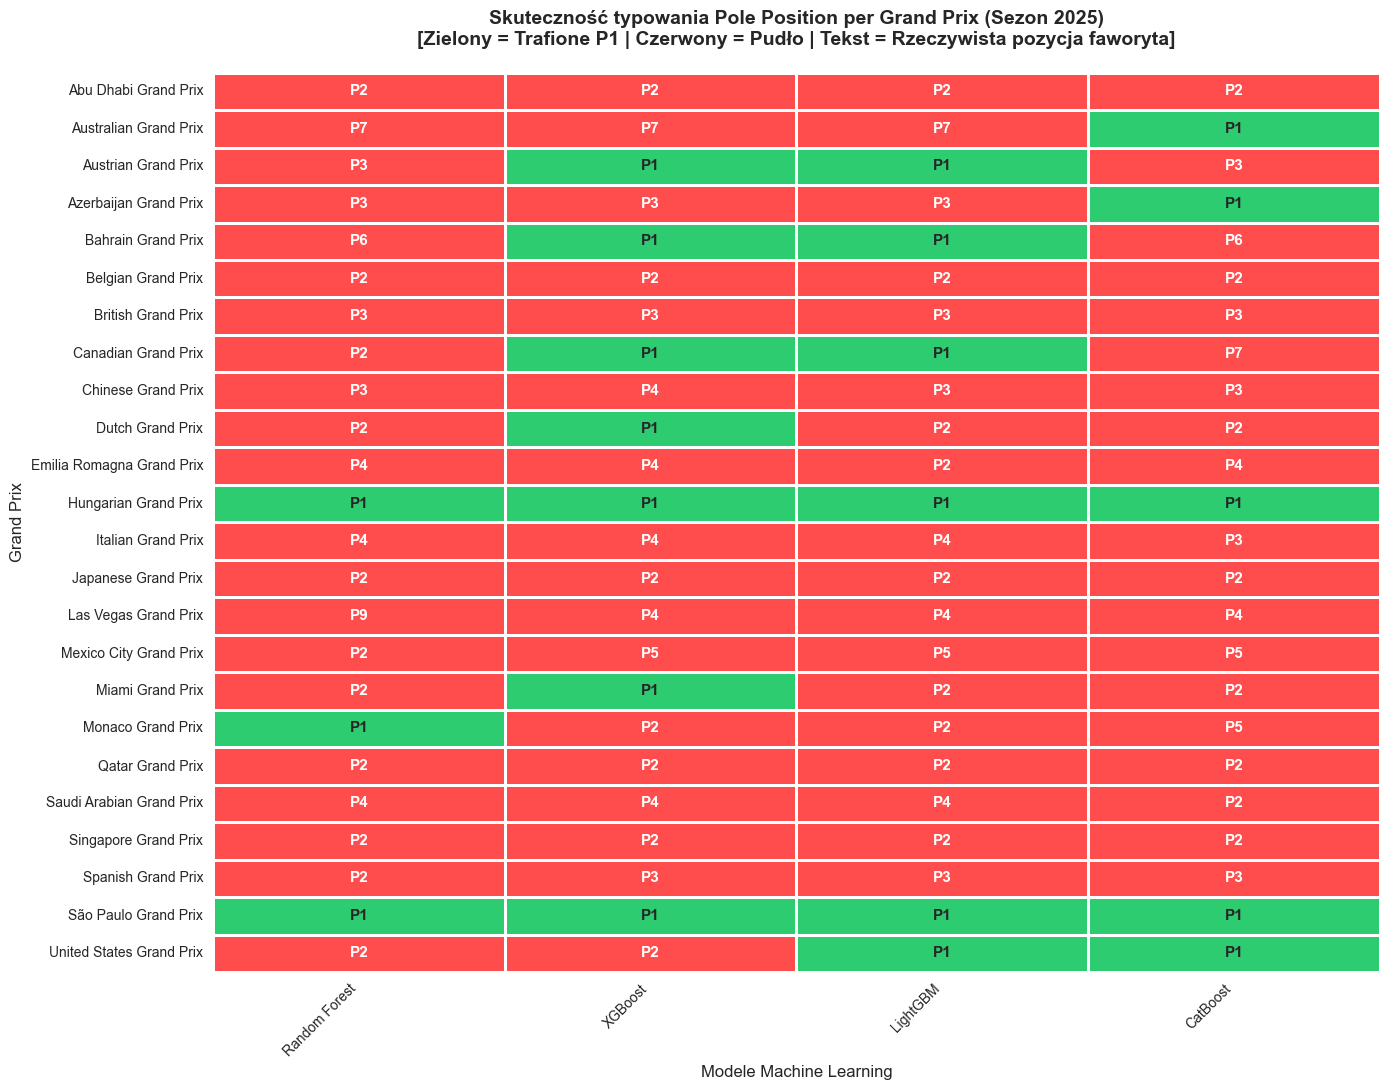

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
import seaborn as sns

# Tabele pomocnicze do zbierania statystyk i przygotowania wykresu
pole_stats = {}
matrix_visual = []  # Dane 0-1 do kolorowania heatmapy
matrix_labels = []  # Teksty (realne pozycje) do wyświetlenia na kafelkach
race_names = []

# Słownik z ikonkami dla czytelności w konsoli
STATUS_ICONS = {True: "🎉 TRAFIONY!", False: "❌ PUDŁO"}

# 1. Przetwarzamy dane dla każdego modelu bezpośrednio słownika
for model_name, preds_val in predictions_dict.items():
    temp_df = pd.DataFrame(
        {
            "Event_Encoded": X_test["EventName"],
            "True_Rank": y_test,
            "Raw_Prediction": preds_val,
        },
        index=X_test.index,
    )

    temp_df["Grand_Prix"] = le.inverse_transform(temp_df["Event_Encoded"])
    temp_df["Driver_Name"] = df.loc[temp_df.index, "Driver"]

    # Obliczamy ogólne MAE dla tego modelu na całym zbiorze testowym
    overall_mae = mean_absolute_error(temp_df["True_Rank"], temp_df["Raw_Prediction"])

    # Sortowanie i wyznaczanie Predicted_Rank (wewnątrz każdego GP)
    temp_df = temp_df.sort_values(
        by=["Event_Encoded", "Raw_Prediction"], ascending=[True, True]
    )
    temp_df["Predicted_Rank"] = (
            temp_df.groupby("Event_Encoded").cumcount() + 1
    )

    # Wyciągamy tylko typowania na P1 dla danego modelu
    model_poles = temp_df[temp_df["Predicted_Rank"] == 1].copy()
    model_poles["Pole_Hit"] = model_poles["True_Rank"] == 1
    model_poles["P1_Error"] = (model_poles["Predicted_Rank"] - model_poles["True_Rank"]).abs()

    # Liczymy zaawansowane metryki pod Twoje wymagania
    total_races = model_poles["Grand_Prix"].nunique()
    successful_poles = model_poles["Pole_Hit"].sum()  # <--- DOKŁADNA ILOŚĆ TRAFIONYCH POLE
    p1_accuracy = (successful_poles / total_races) * 100

    # MAE dedykowane dla samego typu P1
    p1_mae = model_poles["P1_Error"].mean()

    # Top 3 Accuracy: Procent wyścigów, gdzie typowany na P1 zajął miejsca 1, 2 lub 3
    top3_accuracy = (model_poles["True_Rank"] <= 3).mean() * 100

    pole_stats[model_name] = {
        "Ogólne MAE": overall_mae,
        "MAE Typu P1": p1_mae,
        "Trafione P1": int(successful_poles),  # <--- DODANO DO TABELI
        "Skuteczność P1 [%]": p1_accuracy,
        "Top 3 Accuracy [%]": top3_accuracy,
    }

# --- WYŚWIETLANIE 1: ROZBUDOWANA TABELA GLOBALNA ---
print("=========================================================================")
print(" GLOBALNE PODSUMOWANIE SKUTECZNOŚCI MODELI (SEZON 2025):")
print("=========================================================================")
pole_stats_df = pd.DataFrame(pole_stats).T.sort_values(
    by="Skuteczność P1 [%]", ascending=False
)
# Formatowanie wyświetlania, żeby "Trafione P1" było liczbą całkowitą
print(pole_stats_df.to_string(formatters={
    "Ogólne MAE": "{:.2f}".format,
    "MAE Typu P1": "{:.2f}".format,
    "Trafione P1": "{:.0f}".format,
    "Skuteczność P1 [%]": "{:.1f}".format,
    "Top 3 Accuracy [%]": "{:.1f}".format
}))
print("\n" + "=" * 73 + "\n")

# --- WYŚWIETLANIE 2: PRZEJRZYSTY RAPORT PIONOWY PER GP ---
print(" RAPORT SZCZEGÓŁOWY PER GRAND PRIX (SEZON 2025):")
print("-" * 73)

if "RoundNumber" in df.columns:
    unique_races = (
        df[df["Year"] == 2025]
        .sort_values(by="RoundNumber")["EventName"]
        .unique()
    )
else:
    unique_races = sorted(le.inverse_transform(X_test["EventName"].unique()))

# Przygotowanie struktur pod nową heatmapę 0-1
model_names = list(predictions_dict.keys())
for gp in unique_races:
    true_p1_row = df[
        (df["Year"] == 2025) & (df["EventName"] == gp) & (df["SessionRank_Q"] == 1)
        ]
    if true_p1_row.empty:
        continue
    true_p1_driver = true_p1_row["Driver"].values[0]

    print(f"\n🏎️  {gp.upper()}")
    print(f"🥇 Prawdziwe Pole Position (Actual): {true_p1_driver}")
    print(f"   ↳ Typowania modeli:")

    row_visual = {}
    row_labels = {}

    for model_name, preds_val in predictions_dict.items():
        gp_encoded = le.transform([gp])[0]
        model_pred_df = pd.DataFrame(
            {
                "Event_Encoded": X_test["EventName"],
                "True_Rank": y_test,
                "Raw_Prediction": preds_val,
            },
            index=X_test.index,
        )
        model_pred_df["Driver_Name"] = df.loc[model_pred_df.index, "Driver"]
        model_pred_df = model_pred_df[
            model_pred_df["Event_Encoded"] == gp_encoded
            ]

        model_pred_df = model_pred_df.sort_values(by="Raw_Prediction")
        model_pred_df["Predicted_Rank"] = np.arange(len(model_pred_df)) + 1

        predicted_driver = model_pred_df.iloc[0]["Driver_Name"]
        actual_position_of_pred = int(model_pred_df.iloc[0]["True_Rank"])
        is_hit = actual_position_of_pred == 1

        # Logika 0-1 do kolorowania (1 = Trafione P1, 0 = Pudło)
        row_visual[model_name] = 1 if is_hit else 0
        # Tekst na kafelku: Prawdziwa pozycja faworyta (np. "P2", "P1")
        row_labels[model_name] = f"P{actual_position_of_pred}"

        status_text = (
            f"{STATUS_ICONS[is_hit]} (Kierowca {predicted_driver} zajął realnie P{actual_position_of_pred})"
            if not is_hit
            else f"{STATUS_ICONS[is_hit]} ({predicted_driver})"
        )
        print(f"      ▪ {model_name:<15}: {status_text}")

    matrix_visual.append(row_visual)
    matrix_labels.append(row_labels)
    race_names.append(gp)

print("\n" + "=" * 73 + "\n")

# --- WYŚWIETLANIE 3: WIZUALNA MAPA TRAFIEŃ POLE POSITION (0-1 ACCURACY HEATMAP) ---
print(" Generowanie wykresu mapy trafień Pole Position...")
df_visual = pd.DataFrame(matrix_visual, index=race_names)
df_labels = pd.DataFrame(matrix_labels, index=race_names)

plt.figure(figsize=(14, 11))

# Rysujemy rasową heatmapę 0-1 (Zieleń = Trafione P1, Czerwień = Pudło)
sns.heatmap(
    df_visual,
    annot=df_labels,  # Wklejamy etykiety tekstowe "P1", "P2" bezpośrednio na kafelki!
    cmap=sns.color_palette(["#ff4d4d", "#2ecc71"]),  # 0 = Czerwony, 1 = Zielony
    cbar=False,
    linewidths=1,
    linecolor="white",
    fmt="",  # Wymagane przy podawaniu własnych etykiet tekstowych
    annot_kws={"size": 11, "weight": "bold"}
)

plt.title(
    "Skuteczność typowania Pole Position per Grand Prix (Sezon 2025)\n[Zielony = Trafione P1 | Czerwony = Pudło | Tekst = Rzeczywista pozycja faworyta]",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.ylabel("Grand Prix", fontsize=12)
plt.xlabel("Modele Machine Learning", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()